# IRIS 분류 분석 (EDA + 머신러닝)

붓꽃(IRIS) 데이터셋을 활용한 탐색적 데이터 분석 및 다중 분류 모델 비교

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import pickle
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트
font_prop = fm.FontProperties(fname=r'C:\Windows\Fonts\malgun.ttf')
plt.rcParams['font.family'] = font_prop.get_name()
plt.rcParams['axes.unicode_minus'] = False

OUTPUT_DIR = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\13_IRIS_ML\output'
DATA_PATH  = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\13_IRIS_ML\resources\iris.csv'

## 1. 데이터 로드 및 탐색

In [2]:
df = pd.read_csv(DATA_PATH)

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\n결측값:')
print(df.isnull().sum())
print('\n기초 통계:')
print(df.describe())
print('\n샘플:')
df.head()

Shape: (150, 5)

Dtypes:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

결측값:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

기초 통계:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

샘플:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [3]:
print('클래스 분포:')
print(df['species'].value_counts())

# 종 이름 단순화
df['species_short'] = df['species'].str.replace('Iris-', '')

클래스 분포:
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


## 2. EDA — 히스토그램

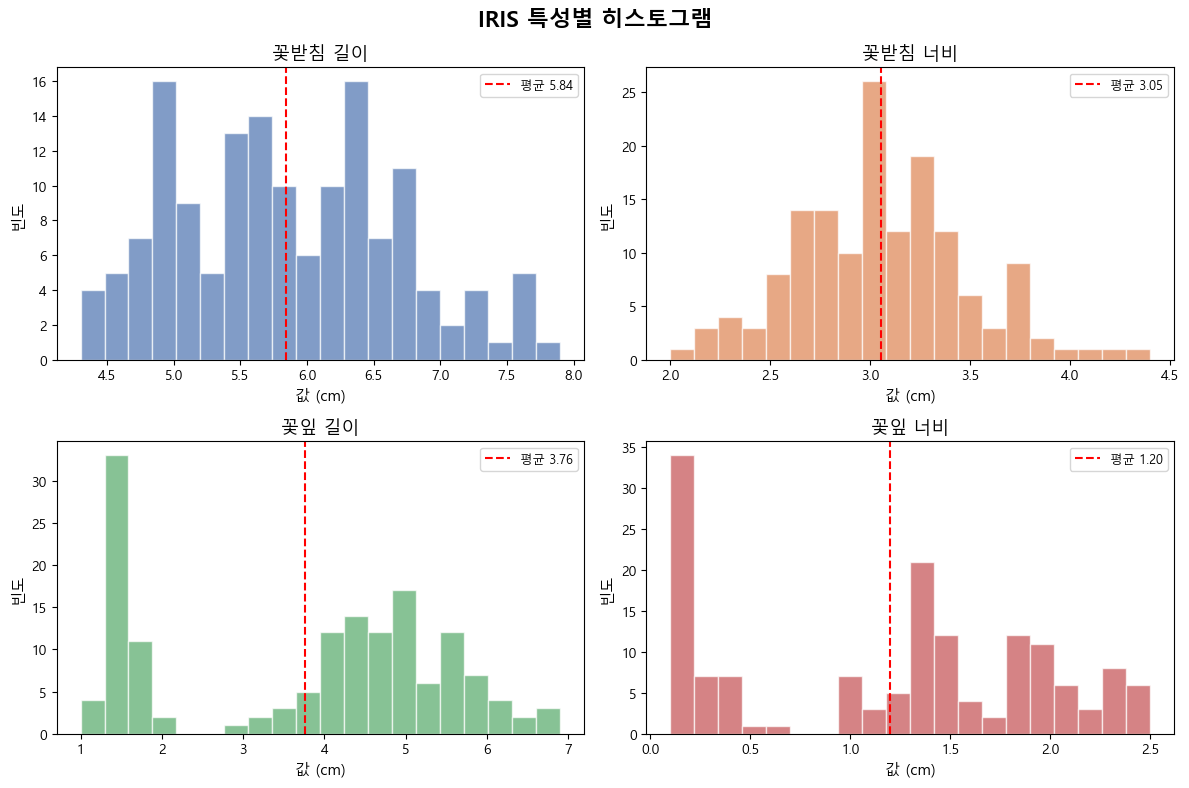

저장: 01_histogram.png


In [4]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
labels   = ['꽃받침 길이', '꽃받침 너비', '꽃잎 길이', '꽃잎 너비']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('IRIS 특성별 히스토그램', fontsize=16, fontweight='bold')

for ax, feat, lbl, col in zip(axes.flat, features, labels, colors):
    ax.hist(df[feat], bins=20, color=col, alpha=0.7, edgecolor='white')
    ax.set_title(lbl, fontsize=13)
    ax.set_xlabel('값 (cm)', fontsize=11)
    ax.set_ylabel('빈도', fontsize=11)
    ax.axvline(df[feat].mean(), color='red', linestyle='--', label=f'평균 {df[feat].mean():.2f}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/01_histogram.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 01_histogram.png')

## 3. EDA — 박스플롯 (종별 비교)

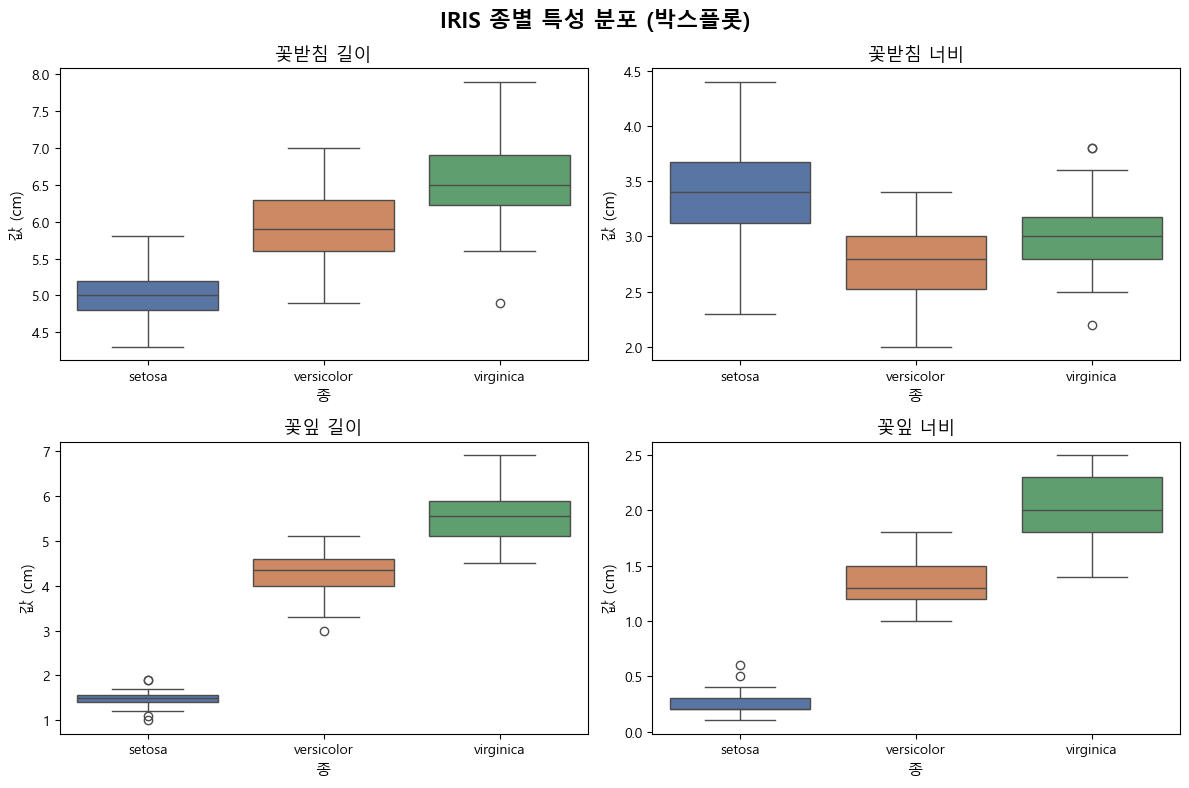

저장: 02_boxplot.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('IRIS 종별 특성 분포 (박스플롯)', fontsize=16, fontweight='bold')

palette = {'setosa': '#4C72B0', 'versicolor': '#DD8452', 'virginica': '#55A868'}

for ax, feat, lbl in zip(axes.flat, features, labels):
    sns.boxplot(data=df, x='species_short', y=feat, palette=palette, ax=ax)
    ax.set_title(lbl, fontsize=13)
    ax.set_xlabel('종', fontsize=11)
    ax.set_ylabel('값 (cm)', fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/02_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 02_boxplot.png')

## 4. EDA — 페어플롯

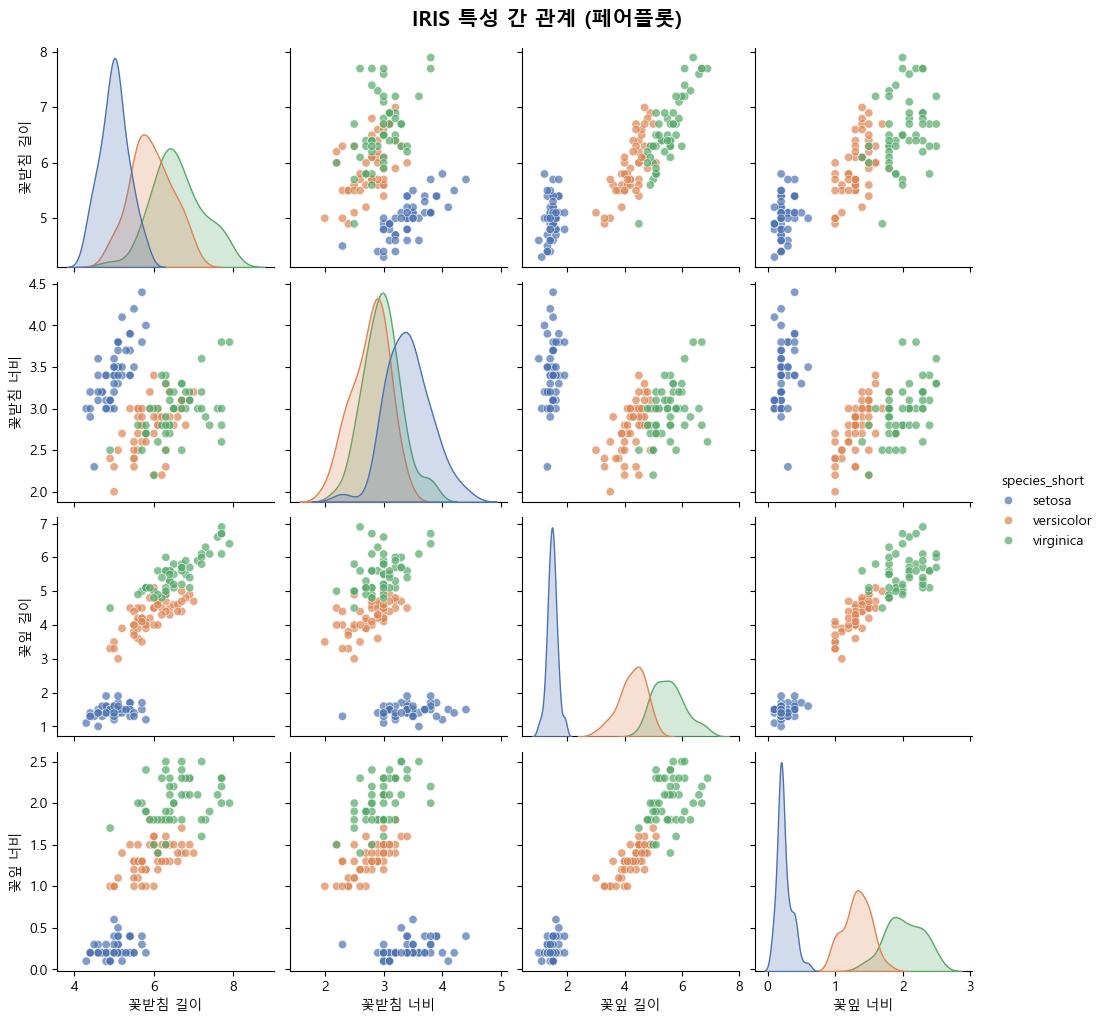

저장: 03_pairplot.png


In [6]:
plot_df = df.copy()
plot_df = plot_df.rename(columns={
    'sepal_length': '꽃받침 길이', 'sepal_width': '꽃받침 너비',
    'petal_length': '꽃잎 길이',  'petal_width': '꽃잎 너비'
})

g = sns.pairplot(plot_df, hue='species_short',
                 palette=palette, diag_kind='kde',
                 plot_kws={'alpha': 0.7})
g.fig.suptitle('IRIS 특성 간 관계 (페어플롯)', y=1.02, fontsize=15, fontweight='bold')

plt.savefig(f'{OUTPUT_DIR}/03_pairplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 03_pairplot.png')

## 5. EDA — 상관관계 히트맵

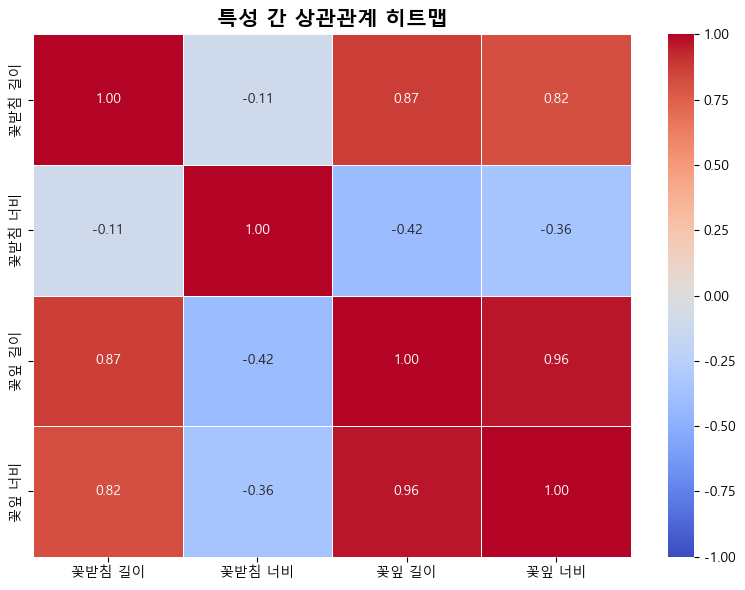

저장: 04_heatmap.png


In [7]:
# 전체 수치형 상관관계
corr = df[features].corr()
corr.index   = labels
corr.columns = labels

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('특성 간 상관관계 히트맵', fontsize=15, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/04_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 04_heatmap.png')

## 6. EDA — 종별 바이올린 플롯

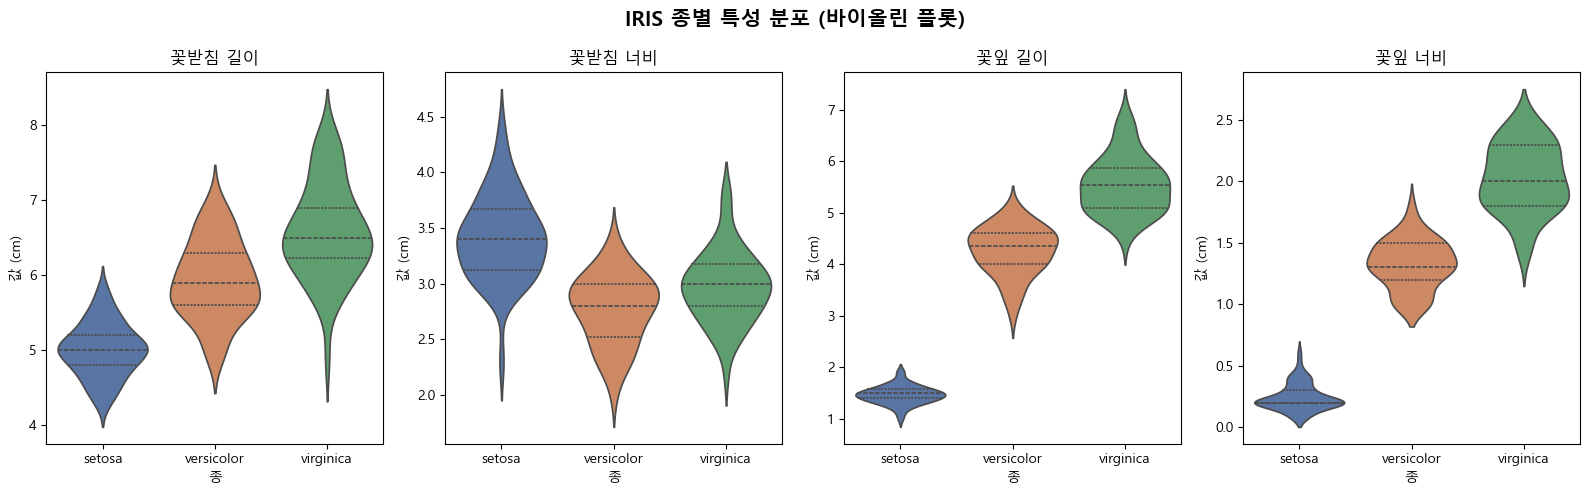

저장: 05_violin.png


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('IRIS 종별 특성 분포 (바이올린 플롯)', fontsize=15, fontweight='bold')

for ax, feat, lbl in zip(axes, features, labels):
    sns.violinplot(data=df, x='species_short', y=feat,
                   palette=palette, inner='quartile', ax=ax)
    ax.set_title(lbl, fontsize=12)
    ax.set_xlabel('종', fontsize=10)
    ax.set_ylabel('값 (cm)', fontsize=10)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/05_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 05_violin.png')

## 7. 머신러닝 — 데이터 준비 및 다중 모델 비교

In [9]:
# 레이블 인코딩
le = LabelEncoder()
df['label'] = le.fit_transform(df['species'])

X = df[features].values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 스케일링
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'훈련: {X_train.shape}, 테스트: {X_test.shape}')

# 모델 정의
models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5),
}

results = {}
for name, model in models.items():
    cv_scores = cross_val_score(model, X_train_s, y_train, cv=5, scoring='accuracy')
    model.fit(X_train_s, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test_s))
    results[name] = {'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(), 'test_acc': test_acc}
    print(f'{name:22s} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test: {test_acc:.4f}')

best_name = max(results, key=lambda k: results[k]['test_acc'])
print(f'\n최고 모델: {best_name} (Test Acc: {results[best_name]["test_acc"]:.4f})')

훈련: (120, 4), 테스트: (30, 4)
Logistic Regression    | CV: 0.9583 ± 0.0264 | Test: 0.9333
Decision Tree          | CV: 0.9417 ± 0.0204 | Test: 0.9000


Random Forest          | CV: 0.9500 ± 0.0167 | Test: 0.9000


Gradient Boosting      | CV: 0.9667 ± 0.0167 | Test: 0.9000
SVM                    | CV: 0.9667 ± 0.0312 | Test: 0.9667
KNN                    | CV: 0.9667 ± 0.0312 | Test: 0.9333

최고 모델: SVM (Test Acc: 0.9667)


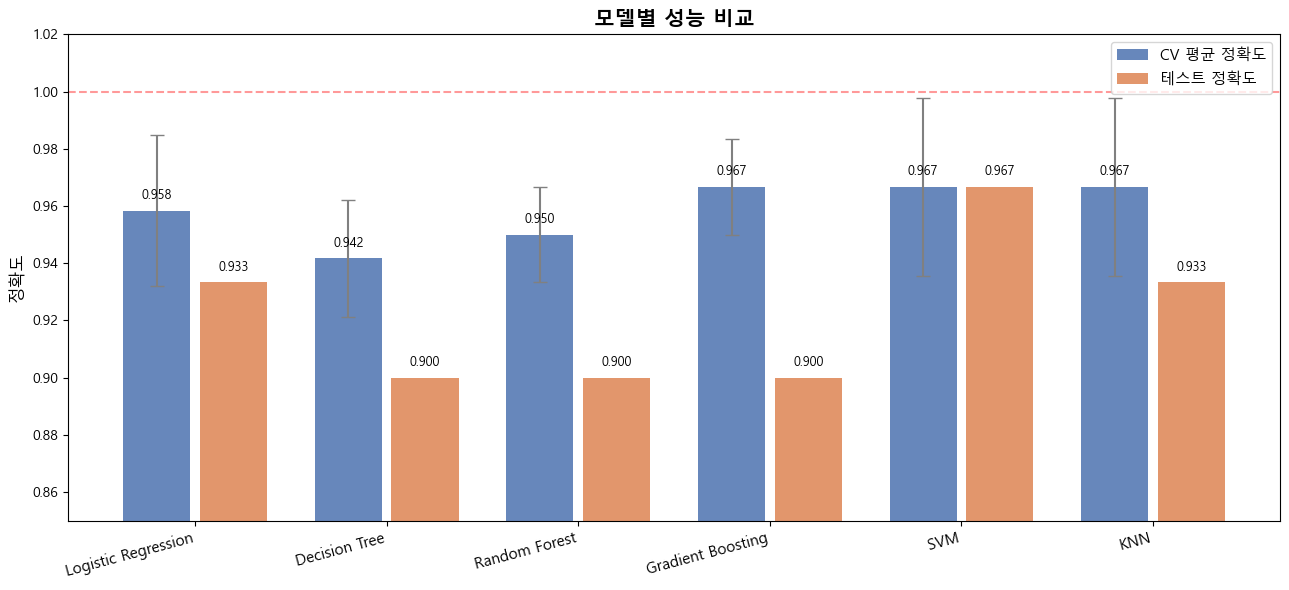

저장: 06_model_comparison.png


In [10]:
# 모델 비교 차트
names     = list(results.keys())
cv_means  = [results[n]['cv_mean']  for n in names]
cv_stds   = [results[n]['cv_std']   for n in names]
test_accs = [results[n]['test_acc'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(13, 6))

bars1 = ax.bar(x - 0.2, cv_means,  0.35, label='CV 평균 정확도', color='#4C72B0', alpha=0.85,
               yerr=cv_stds, capsize=5, ecolor='gray')
bars2 = ax.bar(x + 0.2, test_accs, 0.35, label='테스트 정확도',   color='#DD8452', alpha=0.85)

ax.set_title('모델별 성능 비교', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15, ha='right', fontsize=11)
ax.set_ylabel('정확도', fontsize=12)
ax.set_ylim(0.85, 1.02)
ax.legend(fontsize=11)
ax.axhline(1.0, color='red', linestyle='--', alpha=0.4)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/06_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 06_model_comparison.png')

## 8. 최고 모델 — 혼동 행렬

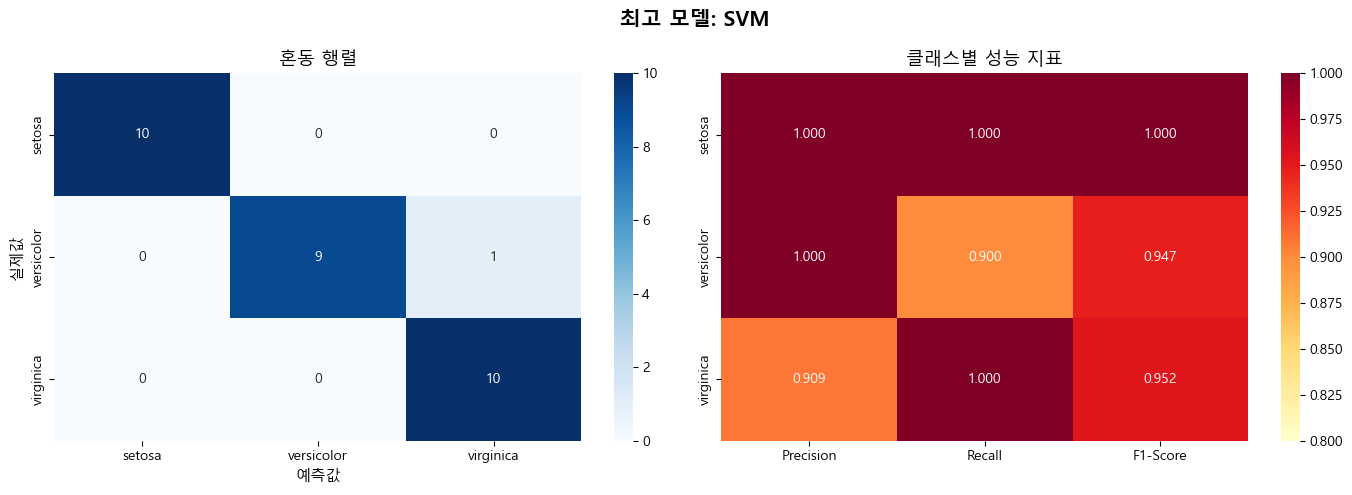

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

저장: 07_confusion_matrix.png


In [11]:
best_model = models[best_name]
y_pred     = best_model.predict(X_test_s)
cm         = confusion_matrix(y_test, y_pred)
class_names = [c.replace('Iris-', '') for c in le.classes_]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'최고 모델: {best_name}', fontsize=15, fontweight='bold')

# 혼동 행렬
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('혼동 행렬', fontsize=13)
axes[0].set_xlabel('예측값', fontsize=11)
axes[0].set_ylabel('실제값', fontsize=11)

# 분류 보고서 히트맵
from sklearn.metrics import precision_score, recall_score, f1_score
metrics_data = []
for i, cls in enumerate(class_names):
    mask = y_test == i
    metrics_data.append({
        'Precision': precision_score(y_test, y_pred, average=None)[i],
        'Recall':    recall_score(y_test, y_pred, average=None)[i],
        'F1-Score':  f1_score(y_test, y_pred, average=None)[i],
    })
metrics_df = pd.DataFrame(metrics_data, index=class_names)
sns.heatmap(metrics_df, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.8, vmax=1.0, ax=axes[1])
axes[1].set_title('클래스별 성능 지표', fontsize=13)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred, target_names=class_names))
print('저장: 07_confusion_matrix.png')

## 9. 결정 경계 시각화 (꽃잎 길이 × 너비)

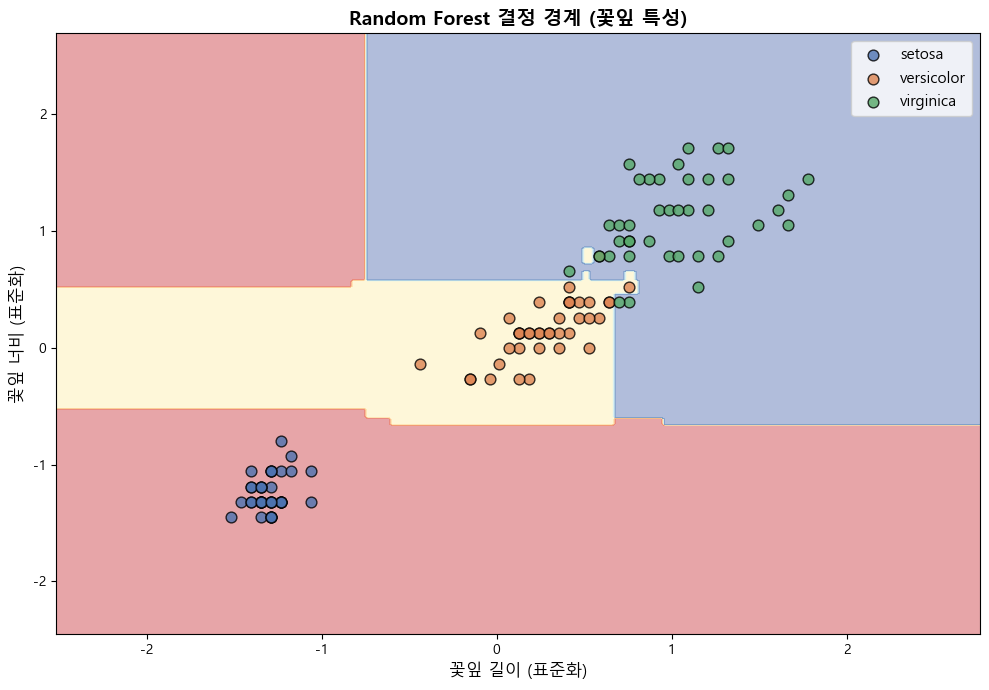

저장: 08_decision_boundary.png


In [12]:
# 꽃잎 특성(2D)으로 결정 경계 시각화
X2 = df[['petal_length', 'petal_width']].values
y2 = df['label'].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s  = scaler2.transform(X2_test)

# Random Forest로 결정 경계
clf2d = RandomForestClassifier(n_estimators=100, random_state=42)
clf2d.fit(X2_train_s, y2_train)

h = 0.02
x_min, x_max = X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1
y_min, y_max = X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = clf2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cmap_bg = plt.cm.RdYlBu
ax.contourf(xx, yy, Z, alpha=0.4, cmap=cmap_bg)

scatter_colors = ['#4C72B0', '#DD8452', '#55A868']
for i, (cls, col) in enumerate(zip(class_names, scatter_colors)):
    mask = y2_train == i
    ax.scatter(X2_train_s[mask, 0], X2_train_s[mask, 1],
               c=col, label=cls, edgecolors='k', s=60, alpha=0.8)

ax.set_xlabel('꽃잎 길이 (표준화)', fontsize=12)
ax.set_ylabel('꽃잎 너비 (표준화)', fontsize=12)
ax.set_title('Random Forest 결정 경계 (꽃잎 특성)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/08_decision_boundary.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: 08_decision_boundary.png')

## 10. 모델 저장

In [13]:
import os
model_path = r'G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\13_IRIS_ML\workflows\iris_model.pkl'

with open(model_path, 'wb') as f:
    pickle.dump({'model': best_model, 'scaler': scaler, 'label_encoder': le}, f)

print(f'모델 저장 완료: {model_path}')
print(f'최고 모델: {best_name}')
print(f'테스트 정확도: {results[best_name]["test_acc"]:.4f}')

모델 저장 완료: G:\내 드라이브\강의자료\Vibe_Coding\Datascience\Test\13_IRIS_ML\workflows\iris_model.pkl
최고 모델: SVM
테스트 정확도: 0.9667
